In [1]:
%load_ext bigquery_magics

# "Will it snow tomorrow?" - The time traveler asked
The following dataset contains climate information from over 9000 stations accross the world. The overall goal of these subtasks will be to predict whether it will snow tomorrow 20 years ago. So if today is 1 April 2025 then the weather we want to forecast is for the 2 April 2005. You are supposed to solve the tasks using Big Query, which can be used in the Jupyter Notebook like it is shown in the following cell. For further information and how to use BigQuery in Jupyter Notebook refer to the Google Docs. 

The goal of this test is to test your coding knowledge in Python, BigQuery and Pandas as well as your understanding of Data Science. If you get stuck in the first part, you can use the replacement data provided in the second part.

In [33]:
%%bigquery
SELECT
*,
FROM `bigquery-public-data.samples.gsod`
LIMIT 20 


Query is running:   0%|          |

Downloading:   0%|          |

,station_number,wban_number,year,month,day,mean_temp,num_mean_temp_samples,mean_dew_point,num_mean_dew_point_samples,mean_sealevel_pressure,...,min_temperature,min_temperature_explicit,total_precipitation,snow_depth,fog,rain,snow,hail,thunder,tornado
0,36010,99999,1929,12,6,49.500000,4,47.500000,4,983.200012,...,NaN,<NA>,NaN,NaN,False,False,False,False,False,False
1,36010,99999,1929,10,7,53.200001,4,49.099998,4,1002.299988,...,NaN,<NA>,NaN,NaN,False,False,False,False,False,False
2,38940,99999,1929,10,14,53.000000,4,50.700001,4,1030.699951,...,NaN,<NA>,0.00,NaN,False,False,False,False,False,False
3,33790,99999,1929,10,18,46.799999,4,41.500000,4,1009.200012,...,NaN,<NA>,0.00,NaN,False,False,False,False,False,False
4,30750,99999,1929,11,24,46.700001,4,43.200001,4,989.000000,...,NaN,<NA>,0.00,NaN,False,False,False,False,False,False
5,30050,99999,1929,12,1,45.700001,4,42.799999,4,991.599976,...,NaN,<NA>,NaN,NaN,False,False,False,False,False,False
6,38940,99999,1929,11,29,54.200001,4,51.799999,4,1001.000000,...,NaN,<NA>,NaN,NaN,False,False,False,False,False,False
7,33790,99999,1929,10,3,52.500000,4,39.299999,4,998.599976,...,NaN,<NA>,0.00,NaN,False,False,False,False,False,False
8,33110,99999,1929,10,28,52.200001,4,47.299999,4,1003.400024,...,NaN,<NA>,NaN,NaN,False,False,False,False,False,False
9,32620,99999,1929,11,3,44.599998,5,40.599998,4,1021.200012,...,NaN,<NA>,0.01,NaN,False,False,False,False,False,False


## Part 1

### 1. Task
Change the date format to 'YYYY-MM-DD' and select the data from 2000 till 2005 for station numbers including and between 725300 and 726300 , and save it as a pandas dataframe. Note the maximum year available is 2010. 

In [34]:
%%bigquery df 

SELECT
  DATE(year, month, day) AS date,
  *
FROM `bigquery-public-data.samples.gsod`
WHERE year BETWEEN 2000 AND 2005
  AND station_number BETWEEN 725300 AND 726300


Query is running:   0%|          |

Downloading:   0%|          |

In [35]:
df.head()

,date,station_number,wban_number,year,month,day,mean_temp,num_mean_temp_samples,mean_dew_point,num_mean_dew_point_samples,...,min_temperature,min_temperature_explicit,total_precipitation,snow_depth,fog,rain,snow,hail,thunder,tornado
0,2000-12-24,725835,99999,2000,12,24,39.700001,4,26.100000,4,...,NaN,<NA>,0.0,NaN,False,False,False,False,False,False
1,2000-11-17,725835,99999,2000,11,17,31.100000,4,18.000000,4,...,NaN,<NA>,0.0,NaN,False,False,False,False,False,False
2,2000-03-03,725848,99999,2000,3,3,56.299999,4,44.599998,4,...,NaN,<NA>,0.0,NaN,False,False,False,False,False,False
3,2000-07-25,726079,99999,2000,7,25,68.000000,4,57.700001,4,...,NaN,<NA>,0.0,NaN,False,False,False,False,False,False
4,2000-10-26,725827,99999,2000,10,26,45.099998,4,23.000000,4,...,NaN,<NA>,0.0,NaN,False,False,False,False,False,False


### 2. Task 
From here you want to work with the data from all stations 725300 to 725330 that have information from 2000 till 2005. 

In [36]:
%%bigquery df_new

SELECT
  DATE(year, month, day) AS date,
  *
FROM `bigquery-public-data.samples.gsod`
WHERE station_number BETWEEN 725300 AND 725330
  AND year BETWEEN 2000 AND 2005


Query is running:   0%|          |

Downloading:   0%|          |

In [37]:
df_new.head()

,date,station_number,wban_number,year,month,day,mean_temp,num_mean_temp_samples,mean_dew_point,num_mean_dew_point_samples,...,min_temperature,min_temperature_explicit,total_precipitation,snow_depth,fog,rain,snow,hail,thunder,tornado
0,2000-03-17,725327,99999,2000,3,17,31.000000,21,20.900000,21,...,NaN,<NA>,0.00,NaN,False,False,False,False,False,False
1,2000-12-06,725326,99999,2000,12,6,13.700000,22,2.400000,22,...,NaN,<NA>,0.00,NaN,False,False,False,False,False,False
2,2000-05-12,725316,99999,2000,5,12,76.800003,23,69.400002,23,...,NaN,<NA>,NaN,NaN,False,False,False,False,False,False
3,2000-08-26,725317,99999,2000,8,26,70.300003,23,66.400002,23,...,NaN,<NA>,0.13,NaN,False,False,False,False,False,False
4,2000-09-15,725305,99999,2000,9,15,55.400002,23,41.799999,23,...,NaN,<NA>,0.02,NaN,False,False,False,False,False,False


Start by checking which year received the most snowfall in our data. 

In [38]:
%%bigquery df_most_snow

SELECT
  year,
  COUNT(CASE WHEN snow is True THEN 1 ELSE NULL END) AS total_snowfall
FROM `bigquery-public-data.samples.gsod`
WHERE station_number BETWEEN 725300 AND 725330
  AND year BETWEEN 2000 AND 2005
GROUP BY year
ORDER BY total_snowfall DESC



Query is running:   0%|          |

Downloading:   0%|          |

In [39]:
df_most_snow

,year,total_snowfall
0,2005,826
1,2000,797
2,2001,759
3,2002,745
4,2003,555
5,2004,262


Add an additional field that indicates the daily change in snow depth measured at every station. And identify the station and day for which the snow depth increased the most.  

In [40]:
%%bigquery df_snow_change

SELECT
  station_number,
  date,
  snow_depth_change
FROM (
  SELECT
    station_number,
    DATE(year, month, day) AS date,
    snow_depth,
    snow_depth - LAG(snow_depth) OVER (PARTITION BY station_number ORDER BY year, month, day) AS snow_depth_change
  FROM
    `bigquery-public-data.samples.gsod`
  WHERE
    year BETWEEN 2000 AND 2005
    AND station_number BETWEEN 725300 AND 725330
)
ORDER BY
  snow_depth_change DESC



Query is running:   0%|          |

Downloading:   0%|          |

In [41]:
df_snow_change.head()

,station_number,date,snow_depth_change
0,725300,2005-01-22,9.8
1,725300,2000-12-11,7.9
2,725300,2002-01-31,7.9
3,725300,2000-02-19,6.0
4,725330,2005-12-09,5.9


In [42]:
import pandas as pd

Do further checks on the remaining dataset, clean or drop data depending on how you see appropriate. 

In [43]:
# drop unnecessary cols
df = df.drop('wban_number', axis=1)
df['date'] = pd.to_datetime(df['date'])

In [44]:
# check ratio of nulls in ccolumns then impute based on a threshold
missing_ratio = df.isnull().mean()
print("Missinng ratio per col:", missing_ratio)

# drop cols with missingness ratio >30%
df = df.drop(columns=missing_ratio[missing_ratio > 0.3].index)

# impute remaining columns with median (robust to outliers) 
for col in df.select_dtypes(include=['number']).columns:
    if df[col].isnull().mean() <= 0.3:  
        median_value = df[col].median() 
        df[col] = df[col].fillna(median_value)


Missinng ratio per col: date                                  0.000000
station_number                        0.000000
year                                  0.000000
month                                 0.000000
day                                   0.000000
mean_temp                             0.000000
num_mean_temp_samples                 0.000000
mean_dew_point                        0.003065
num_mean_dew_point_samples            0.003065
mean_sealevel_pressure                0.389690
num_mean_sealevel_pressure_samples    0.389690
mean_station_pressure                 0.969841
num_mean_station_pressure_samples     0.969841
mean_visibility                       0.023694
num_mean_visibility_samples           0.023694
mean_wind_speed                       0.001980
num_mean_wind_speed_samples           0.001980
max_sustained_wind_speed              0.003980
max_gust_wind_speed                   0.410785
max_temperature                       0.000351
max_temperature_explicit            

In [45]:

print(df['max_temperature_explicit'].isna().sum())
df['max_temperature_explicit'] = df['max_temperature_explicit'].fillna(False)


157


In [46]:
missing_ratio = df.isnull().mean()
print("Missinng ratio per col:", missing_ratio)


Missinng ratio per col: date                           0.0
station_number                 0.0
year                           0.0
month                          0.0
day                            0.0
mean_temp                      0.0
num_mean_temp_samples          0.0
mean_dew_point                 0.0
num_mean_dew_point_samples     0.0
mean_visibility                0.0
num_mean_visibility_samples    0.0
mean_wind_speed                0.0
num_mean_wind_speed_samples    0.0
max_sustained_wind_speed       0.0
max_temperature                0.0
max_temperature_explicit       0.0
total_precipitation            0.0
fog                            0.0
rain                           0.0
snow                           0.0
hail                           0.0
thunder                        0.0
tornado                        0.0
dtype: float64


In [47]:
def check_outliers(df):
    numerical_cols = df.select_dtypes(include=['number']).columns
    
    for col in numerical_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # calculate lower and upper bounds for outliers
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # identify outliers
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outliers_count = outliers.shape[0]
        total_count = df.shape[0]
        
        # calculate the percentage of outliers
        outliers_percentage = (outliers_count / total_count) * 100
        
        print(f"Column: {col} - Outliers: {outliers_percentage:.2f}%")

check_outliers(df)


Column: station_number - Outliers: 0.00%
Column: year - Outliers: 0.00%
Column: month - Outliers: 0.00%
Column: day - Outliers: 0.00%
Column: mean_temp - Outliers: 0.03%
Column: num_mean_temp_samples - Outliers: 23.52%
Column: mean_dew_point - Outliers: 0.16%
Column: num_mean_dew_point_samples - Outliers: 23.60%
Column: mean_visibility - Outliers: 11.85%
Column: num_mean_visibility_samples - Outliers: 23.06%
Column: mean_wind_speed - Outliers: 2.28%
Column: num_mean_wind_speed_samples - Outliers: 15.89%
Column: max_sustained_wind_speed - Outliers: 2.64%
Column: max_temperature - Outliers: 0.30%
Column: total_precipitation - Outliers: 22.29%


In [48]:
def iqr(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # calculate lower and upper bounds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # replace outliers with the corresponding limits
        df[col] = df[col].apply(lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x))
    
    return df

# remove outliers from the numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns
df = iqr(df, numerical_cols)


In [49]:
df.set_index('date', inplace=True)

In [50]:
# add a few more features that might capture seasonality
df['day_of_week'] = df.index.dayofweek  # Monday=0, Sunday=6
df['day_of_year'] = df.index.dayofyear
df['week_of_year'] = df.index.isocalendar().week.astype(int)


In [51]:
# remove constant cols from df
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
df = df.drop(columns=constant_cols)

# calculate cols correlation with snow
correlations = df.corrwith(df['snow']).sort_values(ascending=False)
print(correlations)




thunder                        1.000000
tornado                        1.000000
snow                           1.000000
hail                           1.000000
fog                            1.000000
rain                           1.000000
num_mean_wind_speed_samples    0.095211
station_number                 0.054974
mean_dew_point                 0.045242
day                            0.002607
week_of_year                  -0.002875
day_of_week                   -0.003248
max_sustained_wind_speed      -0.004550
day_of_year                   -0.004563
month                         -0.004976
mean_wind_speed               -0.010742
year                          -0.011183
max_temperature               -0.048319
mean_temp                     -0.076395
max_temperature_explicit      -0.138673
mean_visibility               -0.397194
dtype: float64


In [52]:
# remove columns with perfect correlation to snow
df = df.drop(columns=['tornado', 'fog', 'rain', 'hail', 'thunder'])


### 3. Task
Now it is time to split the data, into a training, evaluation and test set. As a reminder, the date we are trying to predict snow fall for should constitute your test set.

In [53]:
import datetime as dt

cutoff_date = str(dt.datetime.today()- dt.timedelta(days=20*365)).split(' ')[0]


In [54]:
test_df = df[df.index == cutoff_date]  # 20 years ago
train_df = df[df.index < cutoff_date]

In [55]:
X_train = train_df.drop(columns=['snow'])
y_train = train_df['snow']

X_test = test_df.drop(columns=['snow'])
y_test = test_df['snow']

## Part 2
If you made it up to here all by yourself, you can use your prepared dataset to train an algorithm of your choice to forecast whether it will snow on the following date for each station in this dataset:

In [56]:
import datetime as dt

str(dt.datetime.today()- dt.timedelta(days=20*365)).split(' ')[0]

'2005-05-08'

You are allowed to use any library you are comfortable with such as sklearn, tensorflow, keras etc. 
If you did not manage to finish part one feel free to use the data provided in 'coding_challenge.csv' Note that this data does not represent a solution to Part 1. 

In [ ]:
!pip3 install xgboost
!pip3 install scikit-learn
!pip3 install scikit-optimize

In [57]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from skopt import BayesSearchCV

In [58]:
# Initialize classifier
xgb_model = XGBClassifier(objective='binary:logistic', eval_metric='logloss')

# define param search space for bayesian optimization
param_space = {
    'max_depth': (3, 10),  # max depth of trees
    'learning_rate': (0.01, 0.2),  # learning rate
    'n_estimators': (50, 500),  # number of trees
    'subsample': (0.6, 1.0),  # fraction of samples
    'gamma': (0, 5),  # regularization term
    'min_child_weight': (1, 10)  # minimum sum of instance weight
}


In [28]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5) # use for cross validation on temporal data 

opt = BayesSearchCV(xgb_model, param_space, n_iter=3, cv=tscv, n_jobs=-1, verbose=2) 
opt.fit(X_train, y_train) # search for best params 



Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END gamma=2, learning_rate=0.039085163945063235, max_depth=7, min_child_weight=5, n_estimators=263, subsample=0.6269994160902923; total time=   5.0s
[CV] END gamma=2, learning_rate=0.039085163945063235, max_depth=7, min_child_weight=5, n_estimators=263, subsample=0.6269994160902923; total time=   7.9s
[CV] END gamma=2, learning_rate=0.039085163945063235, max_depth=7, min_child_weight=5, n_estimators=263, subsample=0.6269994160902923; total time=  10.5s
[CV] END gamma=2, learning_rate=0.039085163945063235, max_depth=7, min_child_weight=5, n_estimators=263, subsample=0.6269994160902923; total time=  12.1s
[CV] END gamma=2, learning_rate=0.039085163945063235, max_depth=7, min_child_weight=5, n_estimators=263, subsample=0.6269994160902923; total time=  13.7s
Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END gamma=4, learning_rate=0.022378794736271548, max_depth=9, min_child_weight=5, n_estimators=205, subsamp

BayesSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
              estimator=XGBClassifier(base_score=None, booster=None,
                                      callbacks=None, colsample_bylevel=None,
                                      colsample_bynode=None,
                                      colsample_bytree=None, device=None,
                                      early_stopping_rounds=None,
                                      enable_categorical=False,
                                      eval_metric='logloss', feature_types=None,
                                      feature_weights=None, gam...
                                      max_delta_step=None, max_depth=None,
                                      max_leaves=None, min_child_weight=None,
                                      missing=nan, monotone_constraints=None,
                                      multi_strategy=None, n_estimators=None,
                                      n_jobs=None, num_parallel_tree=None, ...),
              n_iter=3, n_jobs=-1,
              search_spaces={'gamma': (0, 5), 'learning_rate': (0.01, 0.2),
                             'max_depth': (3, 10), 'min_child_weight': (1, 10),
                             'n_estimators': (50, 500),
                             'subsample': (0.6, 1.0)},
              verbose=2)

In [59]:
best_model = opt.best_estimator_
# Training metrics 
y_train_pred = best_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

# Test metrics 
y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print("Training Classification Report:\n", classification_report(y_train, y_train_pred))

print(f"Test Accuracy: {test_accuracy:.4f}")
print("Test Classification Report:\n", classification_report(y_test, y_test_pred))

Training Accuracy: 0.9660
Training Classification Report:
               precision    recall  f1-score   support

         0.0       0.97      0.99      0.98    342987
         1.0       0.91      0.83      0.87     54736

    accuracy                           0.97    397723
   macro avg       0.94      0.91      0.93    397723
weighted avg       0.97      0.97      0.97    397723

Test Accuracy: 0.9517
Test Classification Report:
               precision    recall  f1-score   support

         0.0       0.98      0.96      0.97       181
         1.0       0.77      0.88      0.82        26

    accuracy                           0.95       207
   macro avg       0.87      0.92      0.90       207
weighted avg       0.96      0.95      0.95       207



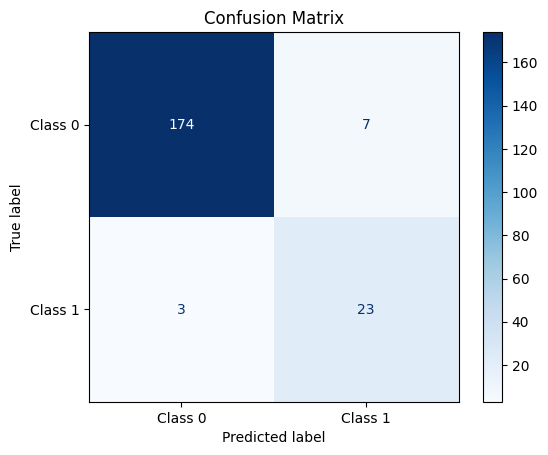

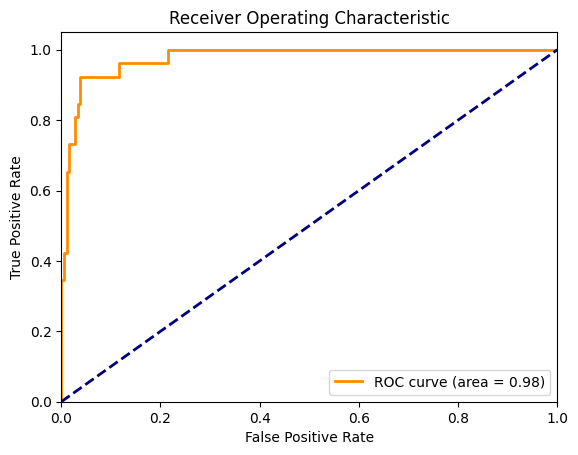

In [60]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
cm_display.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, best_model.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()
